<a href="https://colab.research.google.com/github/WestonWhiteUCD/PanCancer-MultiOmics/blob/main/PanCancer_MultiOmics_Data_Loading_%26_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PanCancer MultiOmics — Notebook 1: Data Loading & EDA

## Purpose
Load and align three TCGA Pan-Cancer Atlas modalities:
- mRNA gene expression (8,314 samples × 3,217 genes)
- DNA methylation (8,314 samples × 3,139 CpG sites)
- Clinical variables (8,314 samples × 6 variables)

Perform exploratory data analysis to understand class distribution,
missing data patterns, and feature variance before any modeling.

## Research Questions addressed here
- RQ5: What is the distribution of cancer types across the dataset?
- RQ7: What are the patterns of missing data across modalities?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 20)
sns.set(style="whitegrid")

## 1. Data Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/My Drive/CompSci Proj')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(os.listdir('/content/drive/My Drive/CompSci Proj'))

['Pan-cancer_mRNA.csv', 'Pan-cancer_Methy.csv', 'Clinical_Rec.csv']


In [ ]:
def normalize_ids(df):
    """Standardize sample IDs to uppercase with no whitespace."""
    df.index = df.index.astype(str).str.upper().str.strip()
    return df

# Load all three modalities
mRNA_df = pd.read_csv('Pan-cancer_mRNA.csv', index_col=0).T
Methy_df = pd.read_csv('Pan-cancer_Methy.csv', index_col=0).T
Clinical_df = pd.read_csv('Clinical_Rec.csv', index_col=0)

# Normalize sample IDs across all three
mRNA_df    = normalize_ids(mRNA_df)
Methy_df   = normalize_ids(Methy_df)
Clinical_df = normalize_ids(Clinical_df)

# Find samples present in ALL three modalities
common_ids = list(set(mRNA_df.index) & set(Methy_df.index) & set(Clinical_df.index))

# Subset each dataframe to common samples only
mRNA_df    = mRNA_df.loc[common_ids]
Methy_df   = Methy_df.loc[common_ids]
Clinical_df = Clinical_df.loc[common_ids]

print(f"Common samples across all modalities: {len(common_ids)}")
print(f"mRNA shape:     {mRNA_df.shape}")
print(f"Methy shape:    {Methy_df.shape}")
print(f"Clinical shape: {Clinical_df.shape}")

Common samples across all modalities: 8314
mRNA shape:     (8314, 3217)
Methy shape:    (8314, 3139)
Clinical shape: (8314, 6)


## 2. Exploratory Data Analysis

In [ ]:
print("Clinical columns:")
print(Clinical_df.columns.tolist())
print()
print("First 5 sample IDs:")
print(Clinical_df.index[:5].tolist())
print()
print("Clinical data preview:")
Clinical_df.head()

Clinical columns:
['status', 'days', 'age_at_initial_pathologic_diagnosis', 'gender', 'pathologic_stage', 'label']

First 5 sample IDs:
['TCGA-BK-A0CA-01', 'TCGA-GM-A2DM-01', 'TCGA-L5-A8NG-01', 'TCGA-DD-A3A9-01', 'TCGA-AT-A5NU-01']

Clinical data preview:


,status,days,age_at_initial_pathologic_diagnosis,gender,pathologic_stage,label
sample,,,,,,
TCGA-BK-A0CA-01,0.0,1064.0,61.0,FEMALE,III,UCEC
TCGA-GM-A2DM-01,0.0,3226.0,57.0,FEMALE,II,BRCA
TCGA-L5-A8NG-01,0.0,1094.0,77.0,MALE,I,ESCA
TCGA-DD-A3A9-01,1.0,931.0,64.0,FEMALE,I,LIHC
TCGA-AT-A5NU-01,0.0,67.0,77.0,MALE,II,KIRP


### 2.1 Missing Value Analysis

In [ ]:
# Calculate percentage of missing values per modality
missing = pd.DataFrame({
    'mRNA (%)':     (mRNA_df.isnull().mean() * 100).describe(),
    'Methylation (%)': (Methy_df.isnull().mean() * 100).describe(),
    'Clinical (%)': (Clinical_df.isnull().mean() * 100)
})

print("=== mRNA Missing Values (%) — feature summary ===")
print((mRNA_df.isnull().mean() * 100).describe().round(4))

print("\n=== Methylation Missing Values (%) — feature summary ===")
print((Methy_df.isnull().mean() * 100).describe().round(4))

print("\n=== Clinical Missing Values (%) — per column ===")
print((Clinical_df.isnull().mean() * 100).round(4))

=== mRNA Missing Values (%) — feature summary ===
count    3217.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
dtype: float64

=== Methylation Missing Values (%) — feature summary ===
count    3139.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
dtype: float64

=== Clinical Missing Values (%) — per column ===
status                                 0.0842
days                                   0.6375
age_at_initial_pathologic_diagnosis    0.5894
gender                                 0.0000
pathologic_stage                       0.0000
label                                  0.0000
dtype: float64


### 2.2 Cancer Type Distribution (RQ5)

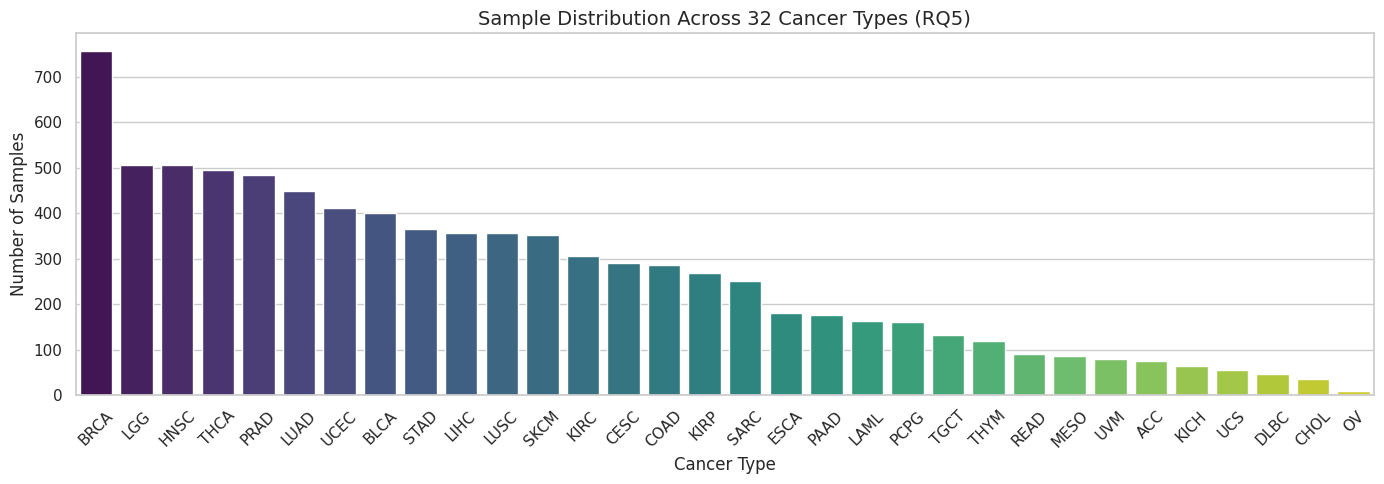

Total cancer types: 32
Largest class:  BRCA (757 samples)
Smallest class: OV (9 samples)
Mean samples per type: 259.8
Std samples per type:  181.8


In [ ]:
# Count samples per cancer type, sorted descending
label_counts = Clinical_df['label'].value_counts().sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index,
            palette='viridis', legend=False, ax=ax)

ax.set_title('Sample Distribution Across 32 Cancer Types (RQ5)', fontsize=14)
ax.set_xlabel('Cancer Type', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Total cancer types: {label_counts.shape[0]}")
print(f"Largest class:  {label_counts.index[0]} ({label_counts.iloc[0]} samples)")
print(f"Smallest class: {label_counts.index[-1]} ({label_counts.iloc[-1]} samples)")
print(f"Mean samples per type: {label_counts.mean():.1f}")
print(f"Std samples per type:  {label_counts.std():.1f}")

### 2.3 Feature Variance Analysis (RQ7)

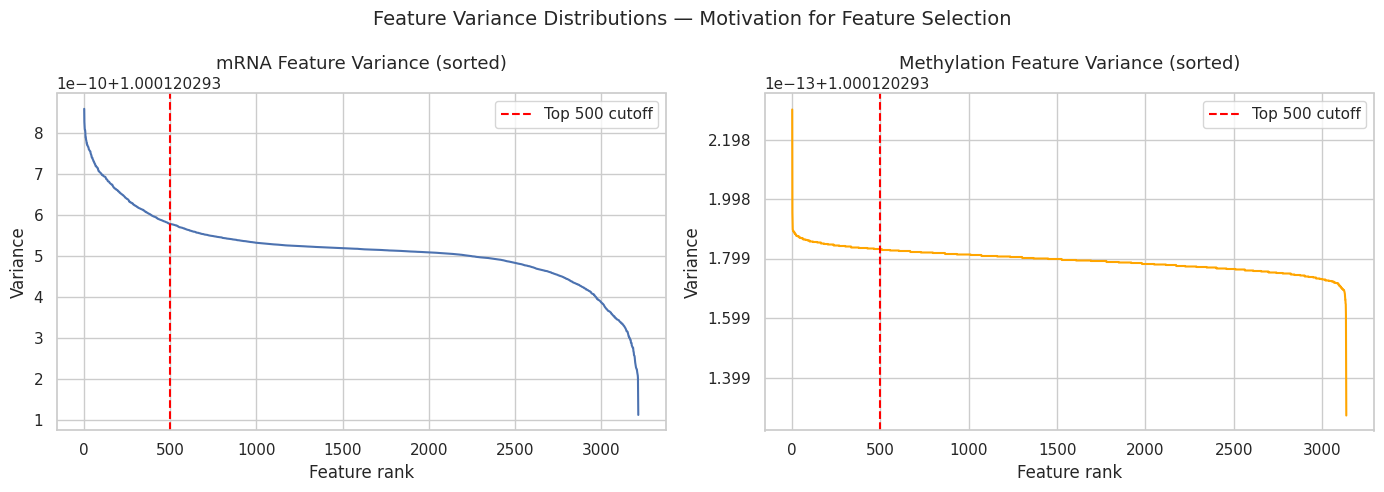

=== mRNA Variance Summary ===
count    3217.0000
mean        1.0001
std         0.0000
min         1.0001
25%         1.0001
50%         1.0001
75%         1.0001
max         1.0001
dtype: float64

Top 500 features capture variance range: 1.0001 – 1.0001

=== Methylation Variance Summary ===
count    3139.0000
mean        1.0001
std         0.0000
min         1.0001
25%         1.0001
50%         1.0001
75%         1.0001
max         1.0001
dtype: float64

Top 500 features capture variance range: 1.0001 – 1.0001


In [ ]:
# Compute per-feature variance for mRNA and methylation
mRNA_var  = mRNA_df.var(axis=0).sort_values(ascending=False)
Methy_var = Methy_df.var(axis=0).sort_values(ascending=False)

# Plot variance distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(len(mRNA_var)), mRNA_var.values)
axes[0].set_title('mRNA Feature Variance (sorted)', fontsize=13)
axes[0].set_xlabel('Feature rank')
axes[0].set_ylabel('Variance')
axes[0].axvline(x=500, color='red', linestyle='--', label='Top 500 cutoff')
axes[0].legend()

axes[1].plot(range(len(Methy_var)), Methy_var.values, color='orange')
axes[1].set_title('Methylation Feature Variance (sorted)', fontsize=13)
axes[1].set_xlabel('Feature rank')
axes[1].set_ylabel('Variance')
axes[1].axvline(x=500, color='red', linestyle='--', label='Top 500 cutoff')
axes[1].legend()

plt.suptitle('Feature Variance Distributions — Motivation for Feature Selection', fontsize=14)
plt.tight_layout()
plt.show()

# Print summary
print("=== mRNA Variance Summary ===")
print(mRNA_var.describe().round(4))
print(f"\nTop 500 features capture variance range: "
      f"{mRNA_var.iloc[499]:.4f} – {mRNA_var.iloc[0]:.4f}")

print("\n=== Methylation Variance Summary ===")
print(Methy_var.describe().round(4))
print(f"\nTop 500 features capture variance range: "
      f"{Methy_var.iloc[499]:.4f} – {Methy_var.iloc[0]:.4f}")

## 3. Summary of Findings

| Finding | Detail |
|---|---|
| Total aligned samples | 8,314 across all three modalities |
| mRNA features | 3,217 genes |
| Methylation features | 3,139 CpG sites |
| Clinical features | 6 variables (2 continuous, 4 categorical) |
| Missing data — mRNA | Effectively 0% |
| Missing data — Methylation | Effectively 0% |
| Missing data — Clinical | Minor (<1%) in age, days, status, pathologic_stage |
| Class imbalance | Severe — BRCA/LUAD dominate, some types <50 samples |
| Feature variance | Sharp drop-off in both modalities — justifies top-500 selection |

### Key decisions motivated by this EDA:
1. **Mean imputation** for clinical continuous variables (age, days) — missingness is minor and random
2. **Top 500 feature selection** per omics modality — variance drop-off shows majority of features carry negligible signal
3. **k=5 clusters** — 32 cancer types with known broad molecular groupings suggests 5 is a reasonable starting point, to be validated with silhouette sweep in Notebook 3
4. **Label withheld from modeling** — used only post-hoc to evaluate biological relevance of clusters

## 4. Save Aligned Data

In [ ]:
# Save aligned dataframes to Google Drive for use in Notebook 2
output_path = '/content/drive/My Drive/CompSci Proj/aligned/'

import os
os.makedirs(output_path, exist_ok=True)

mRNA_df.to_csv(output_path + 'mRNA_aligned.csv')
Methy_df.to_csv(output_path + 'Methy_aligned.csv')
Clinical_df.to_csv(output_path + 'Clinical_aligned.csv')

print("Saved aligned data to Google Drive:")
print(f"  mRNA:     {mRNA_df.shape}")
print(f"  Methy:    {Methy_df.shape}")
print(f"  Clinical: {Clinical_df.shape}")
print(f"\nLocation: {output_path}")

Saved aligned data to Google Drive:
  mRNA:     (8314, 3217)
  Methy:    (8314, 3139)
  Clinical: (8314, 6)

Location: /content/drive/My Drive/CompSci Proj/aligned/
